In [1]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMSerie
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [ ]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout_test.pt")
N = 32
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
IMAGES = 1000

In [4]:
device = "cuda:9"

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    Difference(),
    transforms.Normalize(0.5, 0.5),
])

In [ ]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [ ]:
psnrs_naive = []
psnrs_full= []

mses_naive = []
mses_full = []

x = torch.zeros((IMAGES, 7, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:IMAGES]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(SIGMA_NOISE_START, SIGMA_NOISE_END, 20)

model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)

for sigma in sigmas:

    model_full.set_sigma_noise(sigma)
    model_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e

    with torch.no_grad():
        x_denoised_full = model_full.denoise(x_noisy)
        x_denoised_naive = model_naive.denoise(x_noisy)
        psnrs_full.append(PSNR(x[:, :4].to("cpu"), x_denoised_full[:, :4].to("cpu"), torch.tensor(2)))
        psnrs_naive.append(PSNR(x[:, :4].to("cpu"), x_denoised_naive[:, :4].to("cpu"), torch.tensor(2)))
        mses_naive.append(MSE(x[:, :4].to("cpu"), x_denoised_naive[:, :4].to("cpu")))
        mses_full.append(MSE(x[:, :4].to("cpu"), x_denoised_full[:, :4].to("cpu")))
    
    print(f"Finished {sigma}")

100%|██████████| 32/32 [00:25<00:00,  1.24it/s]


Finished 0.10000000149011612


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Finished 0.1473684161901474


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


...

Finished 0.9052631855010986


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Finished 0.9526315927505493


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Finished 1.0


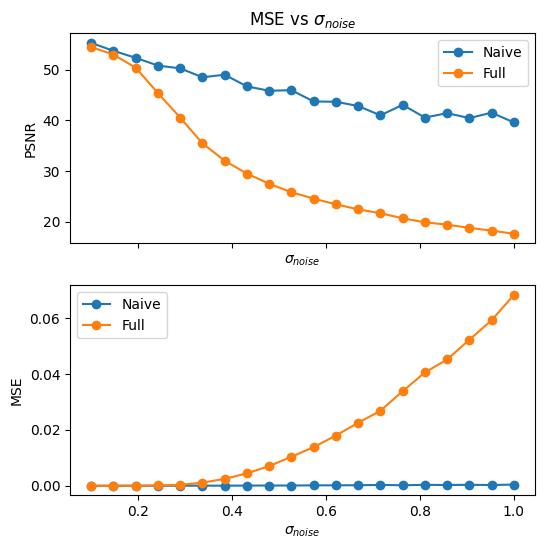

In [8]:
Ns = torch.arange(2, 33)

fig, axis = plt.subplots(2, figsize=(6, 6), sharex=True)

axis[0].plot(sigmas, psnrs_naive, "o-", label="Naive")
axis[0].plot(sigmas, psnrs_full, "o-", label="Full")
axis[0].set_xlabel("$\\sigma_{noise}$")
axis[0].set_ylabel("PSNR")
axis[0].set_title("PSNR vs $\\sigma_{noise}$")
axis[0].legend()

axis[1].plot(sigmas, mses_naive, "o-", label="Naive")
axis[1].plot(sigmas, mses_full, "o-", label="Full")
axis[1].set_xlabel("$\\sigma_{noise}$")
axis[1].set_ylabel("MSE")
axis[0].set_title("MSE vs $\\sigma_{noise}$")
axis[1].legend()

plt.show()